# RSNA 2022 Spine Fracture Detection – Phase 1
## Dataset Exploration and Visualization

This notebook presents the Exploratory Data Analysis (EDA) of the RSNA 2022 Spine Fracture Detection metadata dataset.

The main objective of this phase is to explore the dataset before applying any machine learning or data mining techniques.

In this analysis, we will:

- Understand the dataset structure and its features
- Identify numerical and categorical variables
- Analyze class distribution
- Generate statistical summaries
- Detect missing values and duplicate records
- Identify potential outliers
- Explore correlations between variables
- Perform bivariate and multivariate analysis

This exploratory analysis will help us better understand the data and prepare it for future modeling phases.

In [1]:
# Install Kaggle package (used to download datasets directly from Kaggle)

!pip install kaggle

In [3]:
# Set Kaggle API token as environment variable

import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_2088fde911b1fc8f65b8e09840ede8df"

print("Kaggle token configured successfully.")

Kaggle token configured successfully.


In [4]:
# Download the dataset from Kaggle

!kaggle datasets download -d samuelcortinhas/rsna-2022-spine-fracture-detection-metadata

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/rsna-2022-spine-fracture-detection-metadata
License(s): CC0-1.0
100% 119M/119M [00:01<00:00, 106MB/s] 



In [5]:
# Unzip the downloaded dataset file

import zipfile
import os

zip_file = "rsna-2022-spine-fracture-detection-metadata.zip"
extract_folder = "rsna_metadata"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully.")
print("Files inside the dataset folder:")
print(os.listdir(extract_folder))

Dataset extracted successfully.
Files inside the dataset folder:
['meta_train.csv', 'train_segmented.csv', 'meta_train_clean.csv', 'meta_train_with_vertebrae.csv', 'meta_segmentation_clean.csv', 'meta_segmentation.csv', 'train_vert_fold4.csv', 'train_vert.csv']


In [6]:
# Preview the first 5 rows of every CSV file
import pandas as pd

files = [
    "meta_train.csv",
    "meta_train_clean.csv",
    "meta_train_with_vertebrae.csv",
    "meta_segmentation.csv",
    "meta_segmentation_clean.csv",
    "train_vert.csv",
    "train_vert_fold4.csv",
    "train_segmented.csv"
]

for file in files:
    print("="*60)
    print("FILE:", file)

    temp_df = pd.read_csv(f"rsna_metadata/{file}")

    print("Shape:", temp_df.shape)
    print(temp_df.head(2))
    print()


FILE: meta_train.csv
Shape: (711601, 8)
   Rows  Columns                  SOPInstanceUID  ContentDate  SliceThickness  \
0   512      512  1.2.826.0.1.3680043.6200.1.240     20220727             1.0   
1   512      512   1.2.826.0.1.3680043.6200.1.12     20220727             1.0   

   InstanceNumber           ImagePositionPatient  \
0             240  [-118.530, -103.5302, 143.30]   
1              12  [-118.530, -103.5302, 325.70]   

                             ImageOrientationPatient  
0  [1.00000, 0.00000, 0.00000, 0.00000, 1.00000, ...  
1  [1.00000, 0.00000, 0.00000, 0.00000, 1.00000, ...  

FILE: meta_train_clean.csv
Shape: (711601, 8)
            StudyInstanceUID  Slice  ImageHeight  ImageWidth  SliceThickness  \
0  1.2.826.0.1.3680043.10001      1          512         512           0.625   
1  1.2.826.0.1.3680043.10001      2          512         512           0.625   

   ImagePositionPatient_x  ImagePositionPatient_y  ImagePositionPatient_z  
0                 -52.308     

In [7]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Better visualization style
sns.set_style("whitegrid")


# Load the selected dataset
df = pd.read_csv("rsna_metadata/meta_train_with_vertebrae.csv")


print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (711601, 16)


In [8]:
# Display first 5 rows of the dataset

df.head()

,StudyInstanceUID,Slice,ImageHeight,ImageWidth,SliceThickness,ImagePositionPatient_x,ImagePositionPatient_y,ImagePositionPatient_z,SliceRatio,C1,C2,C3,C4,C5,C6,C7
0,1.2.826.0.1.3680043.10001,1,512,512,0.625,-52.308,-27.712,7.282,0.003731,0,0,0,0,0,0,0
1,1.2.826.0.1.3680043.10001,2,512,512,0.625,-52.308,-27.712,6.657,0.007463,0,0,0,0,0,0,0
2,1.2.826.0.1.3680043.10001,3,512,512,0.625,-52.308,-27.712,6.032,0.011194,0,0,0,0,0,0,0
3,1.2.826.0.1.3680043.10001,4,512,512,0.625,-52.308,-27.712,5.407,0.014925,0,0,0,0,0,0,0
4,1.2.826.0.1.3680043.10001,5,512,512,0.625,-52.308,-27.712,4.782,0.018657,0,0,0,0,0,0,0


### Dataset Description

This dataset contains metadata extracted from cervical spine CT scan images from the RSNA 2022 Spine Fracture Detection dataset.

Each row represents one CT scan slice.

The dataset contains 711,601 instances and 16 features.

The features include:
- Scan identifiers
- Image dimensions
- Slice thickness
- Spatial coordinates
- Relative slice position
- Vertebra labels (C1–C7)

The vertebra columns represent anatomical labels corresponding to the seven cervical vertebrae in the human neck.

In [9]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711601 entries, 0 to 711600
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   StudyInstanceUID        711601 non-null  object 
 1   Slice                   711601 non-null  int64  
 2   ImageHeight             711601 non-null  int64  
 3   ImageWidth              711601 non-null  int64  
 4   SliceThickness          711601 non-null  float64
 5   ImagePositionPatient_x  711601 non-null  float64
 6   ImagePositionPatient_y  711601 non-null  float64
 7   ImagePositionPatient_z  711601 non-null  float64
 8   SliceRatio              711601 non-null  float64
 9   C1                      711601 non-null  int64  
 10  C2                      711601 non-null  int64  
 11  C3                      711601 non-null  int64  
 12  C4                      711601 non-null  int64  
 13  C5                      711601 non-null  int64  
 14  C6                  

In [ ]:
The dataset contains no missing values in any feature. All 711,601 records are complete, which indicates high data quality and reduces the need for imputation during preprocessing.

In [10]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['Slice', 'ImageHeight', 'ImageWidth', 'SliceThickness', 'ImagePositionPatient_x', 'ImagePositionPatient_y', 'ImagePositionPatient_z', 'SliceRatio', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

Categorical columns:
['StudyInstanceUID']


In [11]:
# Check the unique values of vertebra columns

vertebra_cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']

for col in vertebra_cols:
    print(f"{col}: {df[col].unique()}")

C1: [0 1]
C2: [0 1]
C3: [0 1]
C4: [0 1]
C5: [0 1]
C6: [0 1]
C7: [0 1]


0 = Vertebra not visible in this slice  
1 = Vertebra visible in this slice

# 1. Dataset Description

## Dataset Source
This dataset was obtained from the RSNA 2022 Spine Fracture Detection dataset available on Kaggle.

The original competition focuses on detecting cervical spine fractures from CT scan images.

## Domain
This dataset belongs to the medical imaging and healthcare domain, specifically spinal CT image analysis.

## Dataset Size
The dataset contains:

- **711,601 instances (rows)**
- **16 features (columns)**

Each row represents one CT scan slice.

## Target Variables
Unlike traditional datasets with one target column, this dataset contains multiple binary target columns representing cervical vertebrae presence:

- C1
- C2
- C3
- C4
- C5
- C6
- C7

Where:

- **0 = Vertebra not visible in this slice**
- **1 = Vertebra visible in this slice**

## Feature Description

| Feature | Description | Data Type |
|---------|-------------|-----------|
| StudyInstanceUID | Unique identifier for each CT scan study | Categorical (Identifier) |
| Slice | Slice number within the scan | Numerical (Discrete) |
| ImageHeight | Height of image in pixels | Numerical (Discrete) |
| ImageWidth | Width of image in pixels | Numerical (Discrete) |
| SliceThickness | Physical thickness of each CT slice | Numerical (Continuous) |
| ImagePositionPatient_x | X-coordinate of slice position | Numerical (Continuous) |
| ImagePositionPatient_y | Y-coordinate of slice position | Numerical (Continuous) |
| ImagePositionPatient_z | Z-coordinate of slice position | Numerical (Continuous) |
| SliceRatio | Relative slice position within the scan | Numerical (Continuous) |
| C1–C7 | Cervical vertebra labels | Binary / Categorical |

In [12]:
# Define vertebra label columns

vertebra_cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']


# Print class distribution for each vertebra

for col in vertebra_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())


C1 distribution:
C1
0    623326
1     88275
Name: count, dtype: int64

C2 distribution:
C2
0    555070
1    156531
Name: count, dtype: int64

C3 distribution:
C3
0    625377
1     86224
Name: count, dtype: int64

C4 distribution:
C4
0    618042
1     93559
Name: count, dtype: int64

C5 distribution:
C5
0    614102
1     97499
Name: count, dtype: int64

C6 distribution:
C6
0    615976
1     95625
Name: count, dtype: int64

C7 distribution:
C7
0    604698
1    106903
Name: count, dtype: int64


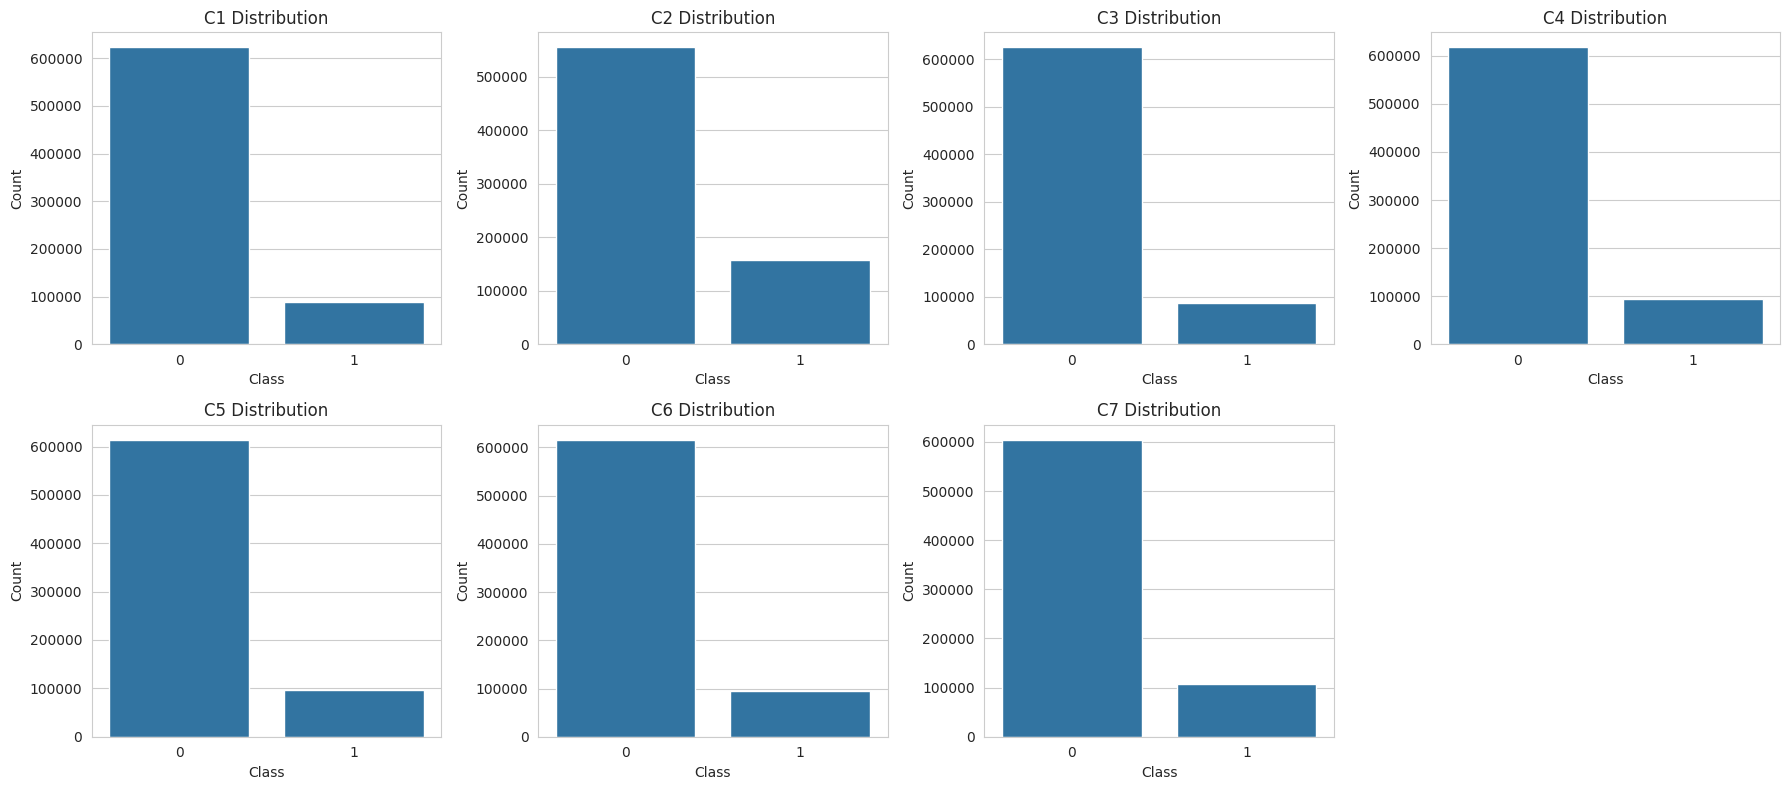

In [13]:
# Plot class distribution for each vertebra

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

axes = axes.flatten()

for i, col in enumerate(vertebra_cols):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel("Count")

# Remove empty subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

## Class Distribution Analysis

The class distribution of the vertebra labels (C1–C7) shows that the dataset is **imbalanced**.

For all vertebrae, class **0** (vertebra not visible in the slice) appears much more frequently than class **1** (vertebra visible in the slice).

For example:

- **C1:** ~12.4% positive samples
- **C2:** ~22.0% positive samples
- **C3:** ~12.1% positive samples
- **C4:** ~13.1% positive samples
- **C5:** ~13.7% positive samples
- **C6:** ~13.4% positive samples
- **C7:** ~15.0% positive samples

This imbalance is expected in medical imaging datasets because not every CT slice contains every vertebra.

### Implications for Modeling

Class imbalance may affect machine learning performance because models may become biased toward the majority class (class 0).

In later phases, this may require techniques such as:

- Class weighting
- Oversampling minority classes
- Undersampling majority classes
- Using evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC instead of accuracy alone

In [14]:
# Generate descriptive statistics for numerical features

stats_summary = df[numerical_cols].describe()

stats_summary

,Slice,ImageHeight,ImageWidth,SliceThickness,ImagePositionPatient_x,ImagePositionPatient_y,ImagePositionPatient_z,SliceRatio,C1,C2,C3,C4,C5,C6,C7
count,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.000000,711601.00000,711601.000000
mean,201.459901,512.281326,512.283736,0.698152,-84.576290,-86.769894,-30.511417,0.501458,0.124051,0.219970,0.121169,0.131477,0.137014,0.13438,0.150229
std,143.653159,8.481772,8.482687,0.175604,25.081311,91.101740,678.834415,0.288659,0.329640,0.414226,0.326324,0.337921,0.343862,0.34106,0.357296
min,1.000000,512.000000,512.000000,0.488281,-207.900000,-357.271484,-1687.000000,0.000924,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,89.000000,512.000000,512.000000,0.625000,-97.280273,-104.687000,-210.135000,0.251445,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,177.000000,512.000000,512.000000,0.625000,-81.500000,-58.300000,-95.938000,0.501567,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,281.000000,512.000000,512.000000,0.800000,-68.000000,-37.900000,12.163000,0.751497,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
max,1082.000000,768.000000,768.000000,1.000000,-8.356445,165.830600,2222.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000


In [15]:
# Add median explicitly and transpose for better readability

stats_summary = df[numerical_cols].describe().T

stats_summary["median"] = df[numerical_cols].median()

stats_summary

,count,mean,std,min,25%,50%,75%,max,median
Slice,711601.0,201.459901,143.653159,1.000000,89.000000,177.000000,281.000000,1082.000000,177.000000
ImageHeight,711601.0,512.281326,8.481772,512.000000,512.000000,512.000000,512.000000,768.000000,512.000000
ImageWidth,711601.0,512.283736,8.482687,512.000000,512.000000,512.000000,512.000000,768.000000,512.000000
SliceThickness,711601.0,0.698152,0.175604,0.488281,0.625000,0.625000,0.800000,1.000000,0.625000
ImagePositionPatient_x,711601.0,-84.576290,25.081311,-207.900000,-97.280273,-81.500000,-68.000000,-8.356445,-81.500000
ImagePositionPatient_y,711601.0,-86.769894,91.101740,-357.271484,-104.687000,-58.300000,-37.900000,165.830600,-58.300000
ImagePositionPatient_z,711601.0,-30.511417,678.834415,-1687.000000,-210.135000,-95.938000,12.163000,2222.000000,-95.938000
SliceRatio,711601.0,0.501458,0.288659,0.000924,0.251445,0.501567,0.751497,1.000000,0.501567
C1,711601.0,0.124051,0.329640,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
C2,711601.0,0.219970,0.414226,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


## Statistical Summary Analysis

Descriptive statistics were generated for all numerical features, including mean, median, standard deviation, minimum, maximum, and quartiles.

### Key Observations

#### 1. Image Dimensions
Both **ImageHeight** and **ImageWidth** have median values of 512 pixels.

However, the maximum value reaches 768 pixels, indicating that some scans have higher resolution than others.

This variation may affect image consistency and may require normalization in later preprocessing stages.

---

#### 2. Slice Number
The slice number ranges from **1 to 1082**.

This indicates that different CT studies contain different numbers of slices.

This is expected in medical imaging datasets.

---

#### 3. Slice Thickness
Slice thickness ranges approximately from **0.49 mm to 1.00 mm**.

This variation reflects different CT acquisition settings across patients or imaging devices.

---

#### 4. Spatial Coordinates
The ImagePositionPatient coordinates (X, Y, Z) show wide ranges.

For example, the Z-coordinate ranges from **-1687 to 2222**, indicating large spatial variation between scan slices.

This is expected because slices are captured at different anatomical positions.

---

#### 5. Slice Ratio
SliceRatio ranges from approximately **0.001 to 1.0**.

This confirms that it represents the normalized slice position within each scan.

---

#### 6. Vertebra Labels (C1–C7)
The mean values of C1–C7 are relatively low.

This confirms the class imbalance observed earlier, where most slices do not contain a specific vertebra.

For example:

- C1 mean ≈ 0.124
- C2 mean ≈ 0.220

Since these are binary columns, the mean represents the proportion of positive samples.

---

### Suspicious or Notable Values

Potentially notable values were observed in:

- **ImageHeight and ImageWidth** (512 vs 768)
- **ImagePositionPatient_z**, which has a very wide range

These values may represent different scanning protocols rather than errors.

Further visualization is needed to confirm whether these are outliers or clinically meaningful variations.

In [16]:
# Check missing values in all columns

missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

Missing values per column:
StudyInstanceUID          0
Slice                     0
ImageHeight               0
ImageWidth                0
SliceThickness            0
ImagePositionPatient_x    0
ImagePositionPatient_y    0
ImagePositionPatient_z    0
SliceRatio                0
C1                        0
C2                        0
C3                        0
C4                        0
C5                        0
C6                        0
C7                        0
dtype: int64


In [17]:

# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [18]:
# Check unique study IDs

unique_studies = df["StudyInstanceUID"].nunique()

print("Number of unique studies:", unique_studies)


# Show first few unique IDs

print("\nSample Study IDs:")
print(df["StudyInstanceUID"].unique()[:10])

Number of unique studies: 2019

Sample Study IDs:
['1.2.826.0.1.3680043.10001' '1.2.826.0.1.3680043.10005'
 '1.2.826.0.1.3680043.10014' '1.2.826.0.1.3680043.10016'
 '1.2.826.0.1.3680043.10032' '1.2.826.0.1.3680043.10041'
 '1.2.826.0.1.3680043.10051' '1.2.826.0.1.3680043.10058'
 '1.2.826.0.1.3680043.10062' '1.2.826.0.1.3680043.1010']


# Data Quality Assessment

The dataset was evaluated for missing values, duplicate records, and inconsistencies.

## 1. Missing Values
No missing values were found in any of the 16 features.

This indicates that the dataset is complete and no imputation is required at this stage.

---

## 2. Duplicate Records
No duplicate rows were found in the dataset.

This confirms that each record represents a unique CT scan slice.

---

## 3. Consistency Check
The StudyInstanceUID column was analyzed to verify identifier consistency.

Results showed:

- **2019 unique CT studies**

The study identifiers follow a consistent formatting structure, indicating no obvious data corruption or formatting inconsistencies.

---

## Planned Handling in Future Phases

Since the dataset contains:

- No missing values
- No duplicate records
- No obvious inconsistencies

No major data cleaning operations are required before modeling.

Only feature scaling or normalization may be considered in later phases depending on the selected machine learning model.

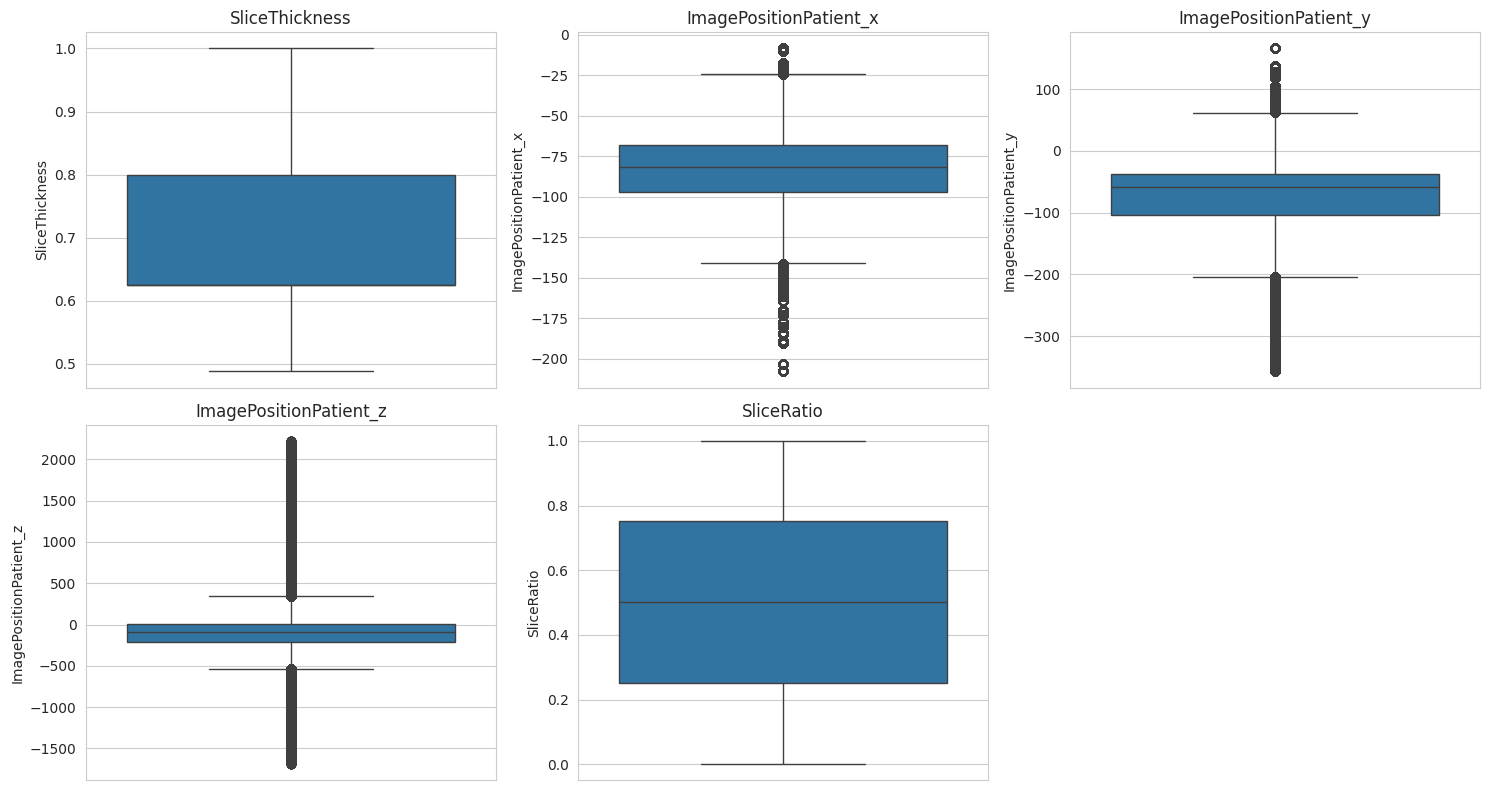

In [19]:
# Select continuous numerical features for outlier detection

continuous_cols = [
    'SliceThickness',
    'ImagePositionPatient_x',
    'ImagePositionPatient_y',
    'ImagePositionPatient_z',
    'SliceRatio'
]


# Create boxplots

plt.figure(figsize=(15,8))

for i, col in enumerate(continuous_cols):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
from scipy.stats import zscore

# Calculate outliers using z-score

for col in continuous_cols:

    z_scores = np.abs(zscore(df[col]))

    outliers = (z_scores > 3).sum()

    print(f"{col}: {outliers} outliers")

SliceThickness: 0 outliers
ImagePositionPatient_x: 10188 outliers
ImagePositionPatient_y: 0 outliers
ImagePositionPatient_z: 8599 outliers
SliceRatio: 0 outliers


## Why These Features Were Selected for Outlier Detection

Outlier detection was applied only to continuous numerical features:

- SliceThickness
- ImagePositionPatient_x
- ImagePositionPatient_y
- ImagePositionPatient_z
- SliceRatio

These features were selected because they represent continuous physical measurements or spatial coordinates, where unusually extreme values may indicate abnormal observations, measurement variations, or data inconsistencies.

The following features were excluded:

### StudyInstanceUID
This is a unique identifier rather than a measurable feature, so outlier detection is not meaningful.

### ImageHeight and ImageWidth
These features mainly contain fixed scanner resolutions (such as 512 or 768 pixels) rather than naturally varying continuous measurements.

### Vertebra Labels (C1–C7)
These are binary categorical variables containing only:

- 0 = Vertebra not visible
- 1 = Vertebra visible

Since binary variables only contain two valid values, outlier detection is not applicable.

---

## Why Z-score Threshold |z| > 3 Was Used

Z-score measures how far a value is from the mean in terms of standard deviations:


::contentReference[oaicite:0]{index=0}


Where:

- x = observed value
- μ = mean
- σ = standard deviation

A threshold of:

|z| > 3

was selected based on the empirical rule of normal distributions.

According to this rule:

:contentReference[oaicite:1]{index=1}

Therefore, values beyond ±3 standard deviations are statistically rare and are commonly considered potential outliers.

In medical imaging, however, such outliers may represent clinically meaningful anatomical variations rather than errors.# Outlier Detection Analysis

Outlier detection was performed using both:

- Box plots (visual detection)
- Z-score analysis (statistical detection)

A threshold of |z| > 3 was used to identify potential outliers.

## Results

| Feature | Number of Outliers |
|---------|-------------------|
| SliceThickness | 0 |
| ImagePositionPatient_x | 10,188 |
| ImagePositionPatient_y | 0 |
| ImagePositionPatient_z | 8,599 |
| SliceRatio | 0 |

## Interpretation

The majority of outliers were found in:

- ImagePositionPatient_x
- ImagePositionPatient_z

These features represent spatial coordinates of CT scan slices in 3D anatomical space.

In medical imaging datasets, such outliers are likely to represent:

- Different patient positioning
- Different scan ranges
- Variations in anatomical coverage

Therefore, these outliers are more likely to be **clinically meaningful variations** rather than noise or data errors.

No immediate removal of these outliers is recommended before further analysis.

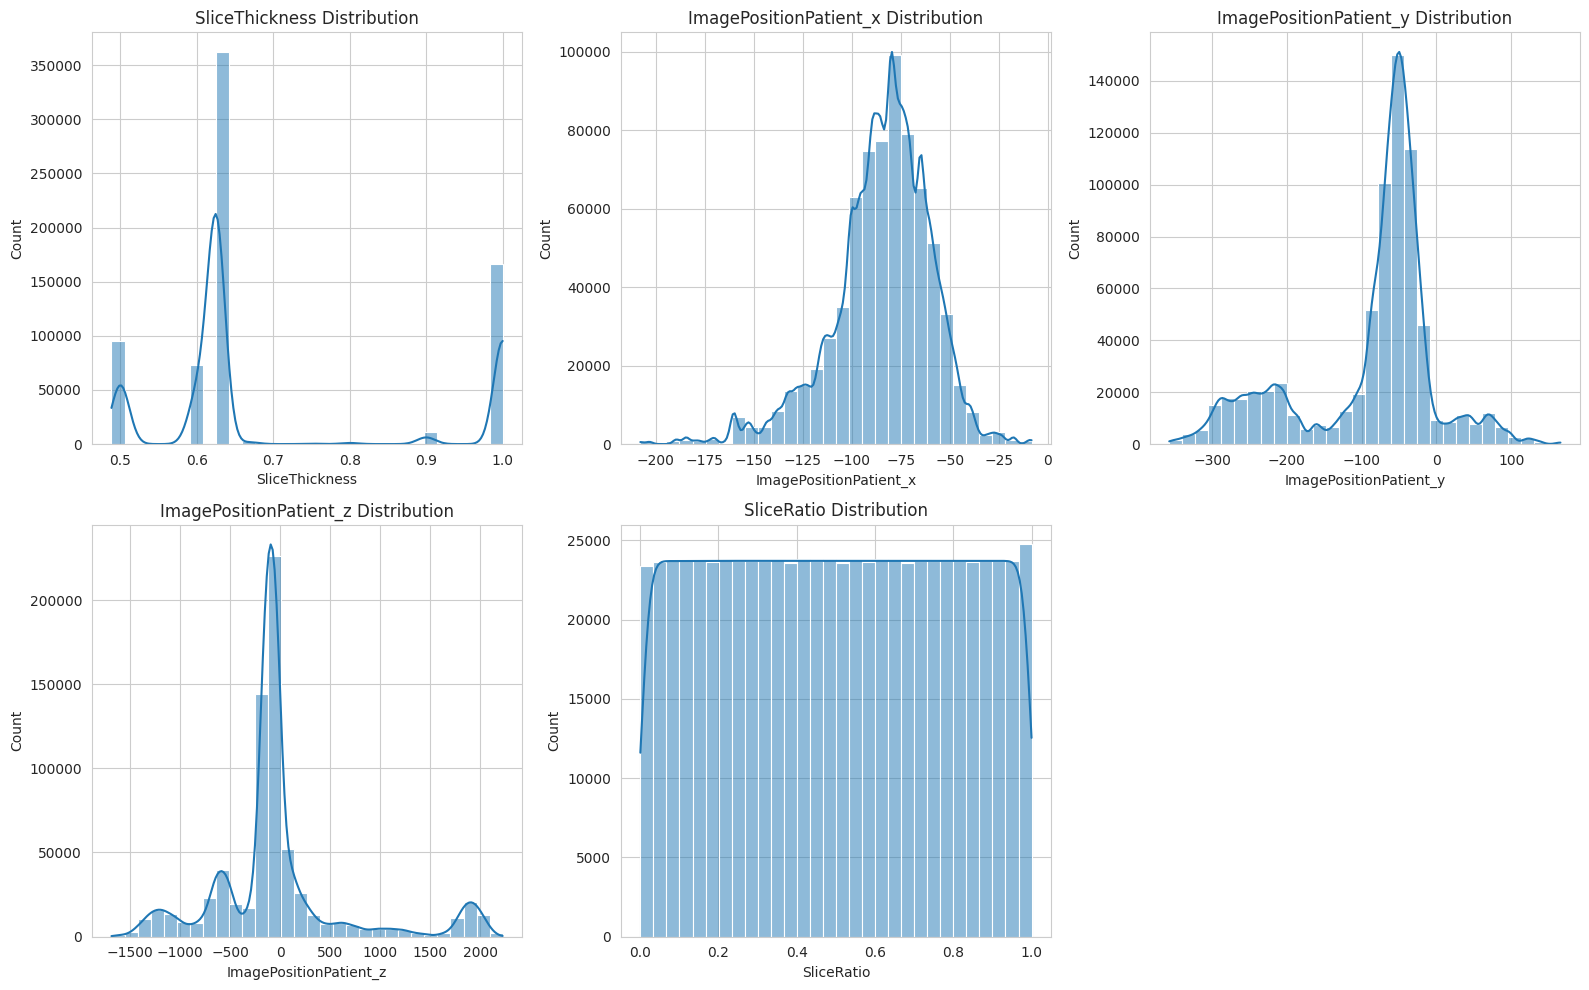

In [21]:
# Plot feature distributions for continuous variables

plt.figure(figsize=(16,10))

for i, col in enumerate(continuous_cols):

    plt.subplot(2,3,i+1)

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

# Feature Distribution Analysis

Histograms with Kernel Density Estimation (KDE) were used to analyze the distribution of continuous numerical features.

## 1. SliceThickness

The SliceThickness distribution is **multimodal**, with several distinct peaks.

This indicates that multiple CT scanning protocols were used, with common slice thickness values such as approximately:

- 0.5 mm
- 0.625 mm
- 1.0 mm

This is expected in medical imaging datasets.

The distribution is not normal.

---

## 2. ImagePositionPatient_x

The X-coordinate distribution appears approximately **bell-shaped**, but shows mild skewness and some irregular peaks.

This suggests that patient positioning is generally consistent, with some variation across scans.

The distribution is close to normal but not perfectly Gaussian.

---

## 3. ImagePositionPatient_y

The Y-coordinate distribution shows **left skewness** and multiple peaks.

This indicates anatomical or scanning variations across patients.

The distribution is not perfectly normal.

---

## 4. ImagePositionPatient_z

The Z-coordinate shows a **wide multimodal distribution** with multiple peaks and long tails.

This is expected because the Z-axis represents slice depth across the cervical spine and different studies may contain different scan lengths.

This distribution is clearly not normal.

---

## 5. SliceRatio

The SliceRatio distribution appears approximately **uniform** between 0 and 1.

This confirms that SliceRatio represents the normalized slice position within each scan.

No skewness or abnormal clustering is observed.

---

## Overall Findings

Most features do not follow a normal distribution.

This is common in medical imaging datasets due to:

- Different scanner settings
- Different patient anatomy
- Different acquisition protocols

This may influence the choice of preprocessing and machine learning algorithms in later phases.

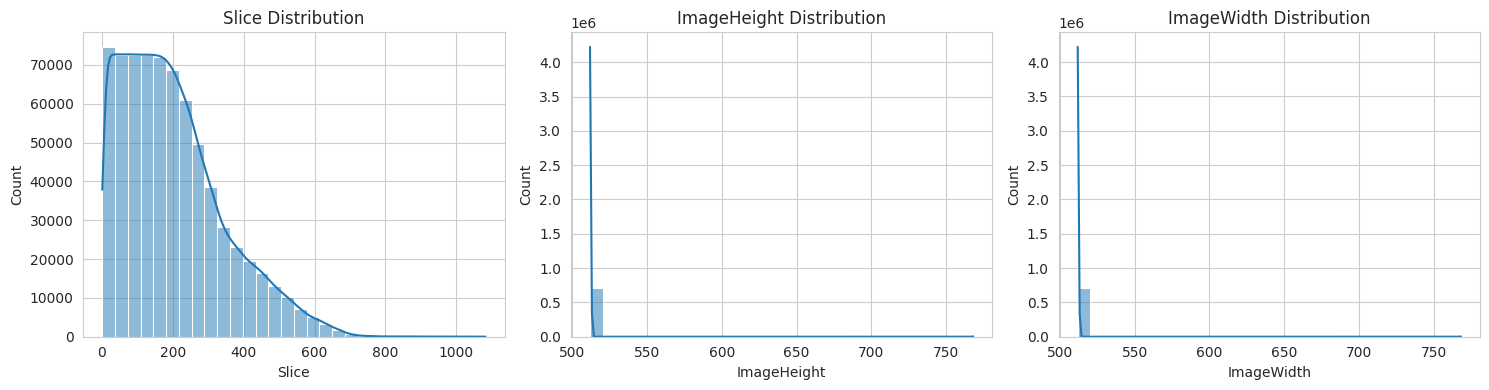

In [22]:
# Remaining numerical features

remaining_numerical = [
    'Slice',
    'ImageHeight',
    'ImageWidth'
]


plt.figure(figsize=(15,4))

for i, col in enumerate(remaining_numerical):

    plt.subplot(1,3,i+1)

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins=30
    )

    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

## Additional Numerical Feature Distributions

### 1. Slice

The Slice distribution shows a **right-skewed distribution**.

Most slices are concentrated in lower slice numbers, while fewer studies contain very large numbers of slices.

This is expected because CT studies may vary in scan length and anatomical coverage.

---

### 2. ImageHeight

The ImageHeight distribution shows a strong concentration around **512 pixels**, with a smaller number of scans reaching **768 pixels**.

This indicates that most CT images were captured using a standard resolution.

The distribution is highly discrete and not normally distributed.

---

### 3. ImageWidth

The ImageWidth distribution shows the same pattern as ImageHeight.

Most images have a width of **512 pixels**, with fewer scans at **768 pixels**.

This reflects different scanner acquisition settings rather than natural variation.

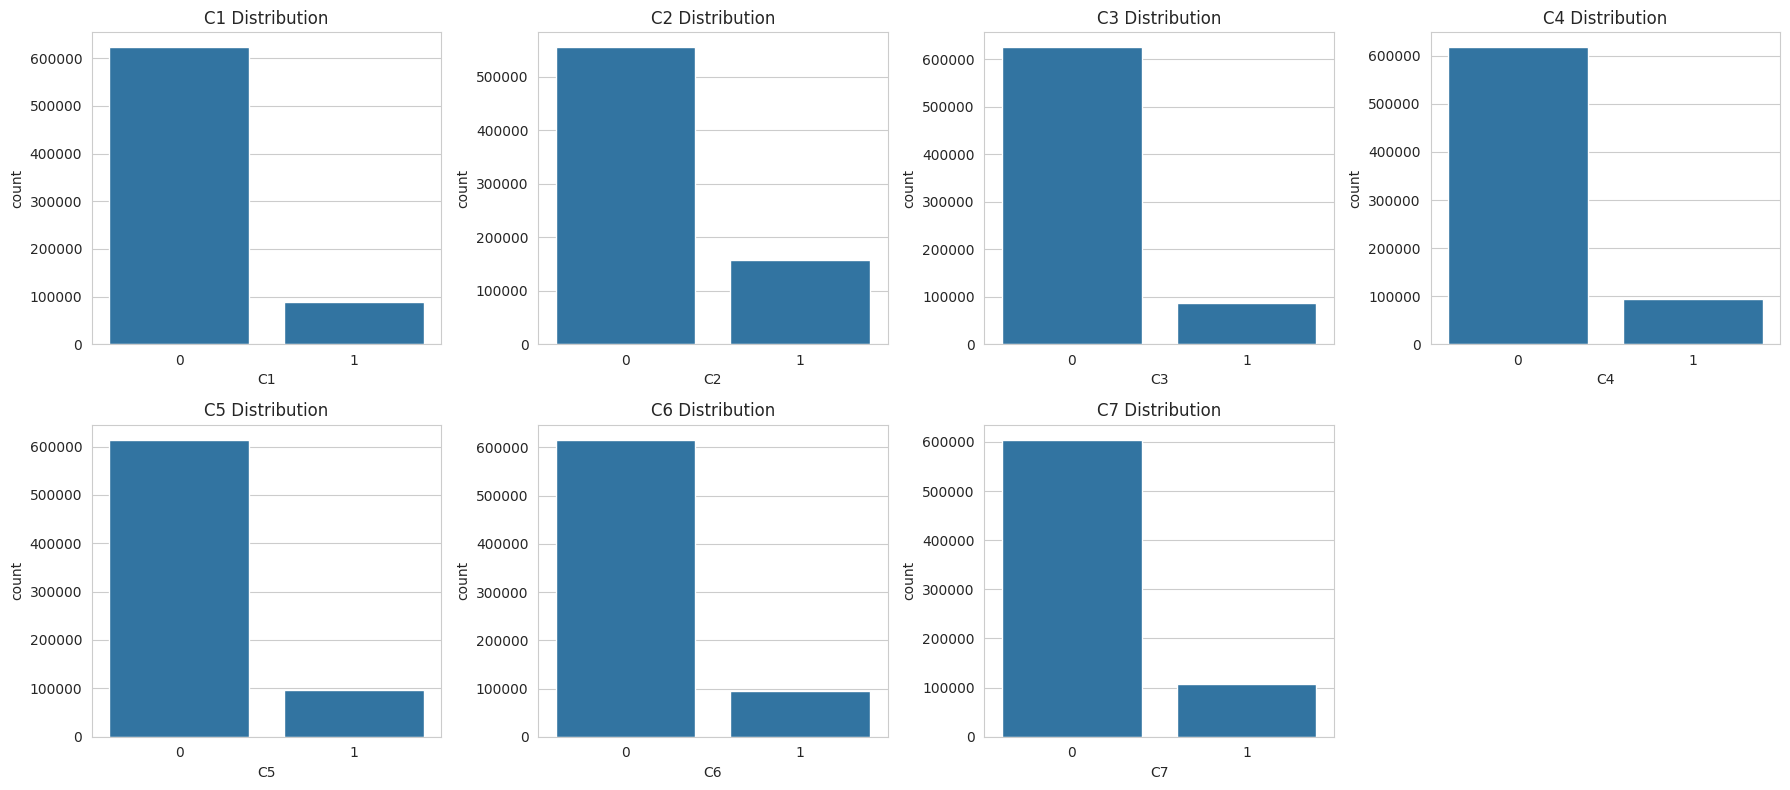

In [23]:
# Plot binary vertebra label distributions

fig, axes = plt.subplots(2, 4, figsize=(18,8))

axes = axes.flatten()

for i, col in enumerate(vertebra_cols):

    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Distribution")

# Remove extra subplot
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

## Categorical / Binary Feature Distributions

The vertebra label columns (C1–C7) were analyzed using bar charts.

Each vertebra column contains binary values:

- 0 = Vertebra not visible in the slice
- 1 = Vertebra visible in the slice

### Observations

All vertebra features show **imbalanced binary distributions**, where class 0 appears much more frequently than class 1.

This indicates that most CT slices do not contain every vertebra, which is expected because each slice captures only a specific anatomical region.

The distributions are therefore **not balanced** and not normally distributed.

### Implications

These imbalanced label distributions may affect future machine learning models, as models may become biased toward predicting the majority class.

This should be considered in later modeling phases using techniques such as:

- Class weighting
- Resampling
- Using metrics such as Precision, Recall, and F1-score

### StudyInstanceUID

The StudyInstanceUID feature was not visualized using a bar chart because it contains 2019 unique identifiers.

As an identifier feature, it does not represent a measurable distribution and is mainly used to distinguish between different CT studies.

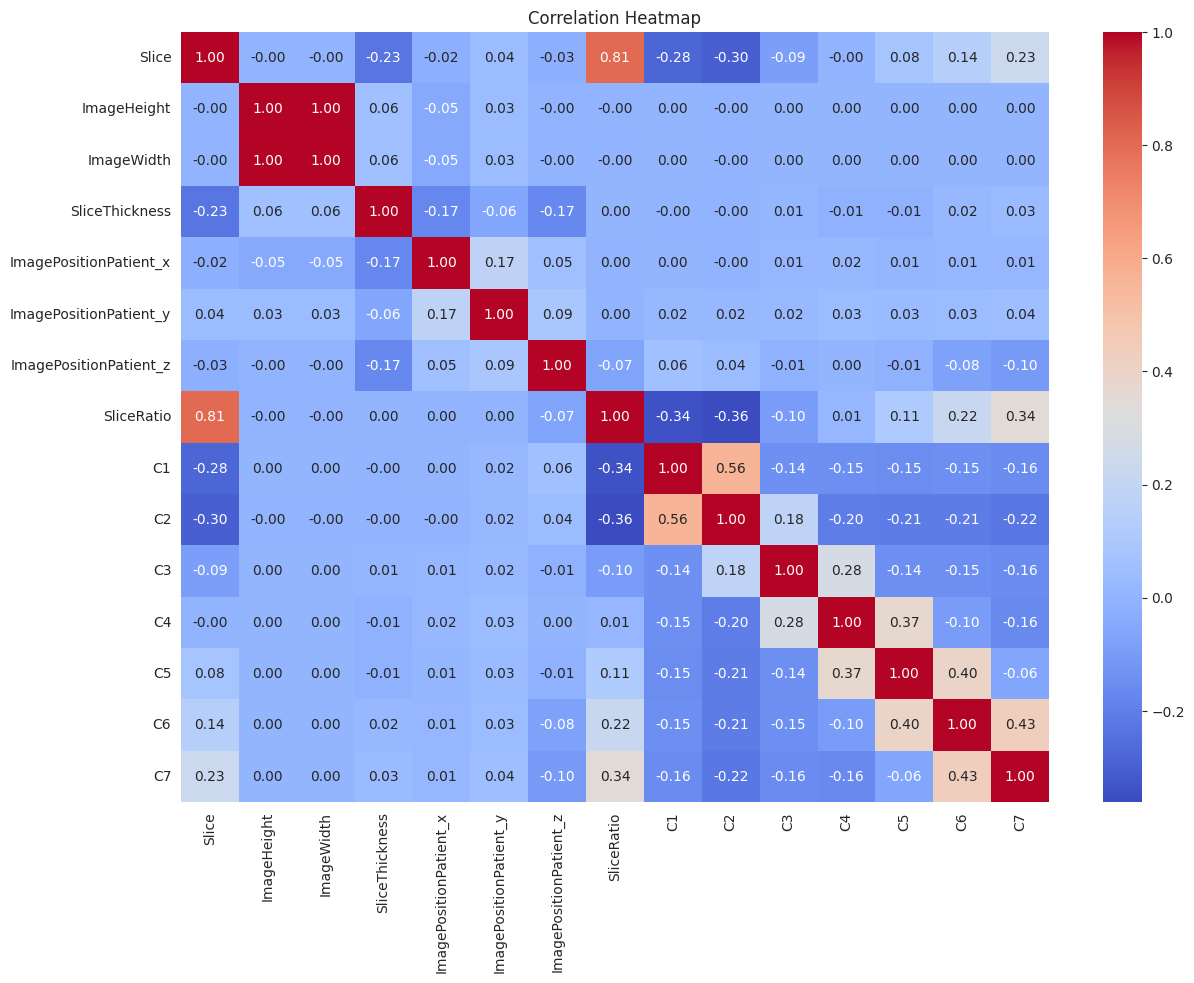

In [24]:
# Compute correlation matrix

correlation_matrix = df[numerical_cols].corr()


# Plot heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
# Find strongly correlated feature pairs

strong_pairs = []

threshold = 0.7

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= threshold:
            strong_pairs.append(
                (feature_1, feature_2, corr_value)
            )


print("Strong correlations (|r| >= 0.7):\n")

for pair in strong_pairs:
    print(pair)

Strong correlations (|r| >= 0.7):

('Slice', 'SliceRatio', np.float64(0.8067050512642866))
('ImageHeight', 'ImageWidth', np.float64(0.9998828060674665))


## Why Was a Correlation Threshold of |r| ≥ 0.7 Used?

Pearson correlation coefficient ranges between:

- -1 = Perfect negative correlation
- 0 = No linear correlation
- +1 = Perfect positive correlation

In statistical analysis, correlation strength is commonly interpreted as:

| Correlation Range | Interpretation |
|------------------|----------------|
| 0.0 – 0.3 | Weak |
| 0.3 – 0.7 | Moderate |
| 0.7 – 1.0 | Strong |

A threshold of:

|r| ≥ 0.7

was used to identify strongly correlated features that may indicate:

- Feature redundancy
- Multicollinearity
- Duplicate information

These features may require further consideration in future modeling phases.

# Correlation Analysis

A Pearson correlation heatmap was generated for all numerical features to identify relationships between variables.

## Strong Correlations Identified

### 1. Slice vs SliceRatio
Correlation:

**r ≈ 0.81**

This strong positive correlation is expected because SliceRatio is derived from the slice position within each scan.

As the slice number increases, the normalized slice ratio also increases.

This indicates that these two features contain related information.

---

### 2. ImageHeight vs ImageWidth
Correlation:

**r ≈ 1.00**

This almost perfect positive correlation indicates that image height and image width increase together.

This is expected because CT images are typically stored using square resolutions such as:

- 512 × 512
- 768 × 768

This suggests possible feature redundancy.

One of these features may be removed in future modeling phases if dimensionality reduction is needed.

---

## Additional Observations

Moderate correlations were observed between neighboring vertebra labels.

For example:

- C1 and C2
- C5 and C6
- C6 and C7

This is anatomically meaningful because adjacent cervical vertebrae often appear in nearby CT slices.

---

## Modeling Implications

Strongly correlated features may introduce multicollinearity in certain machine learning models.

In later phases, highly redundant features may be:

- Removed
- Combined
- Transformed using dimensionality reduction techniques

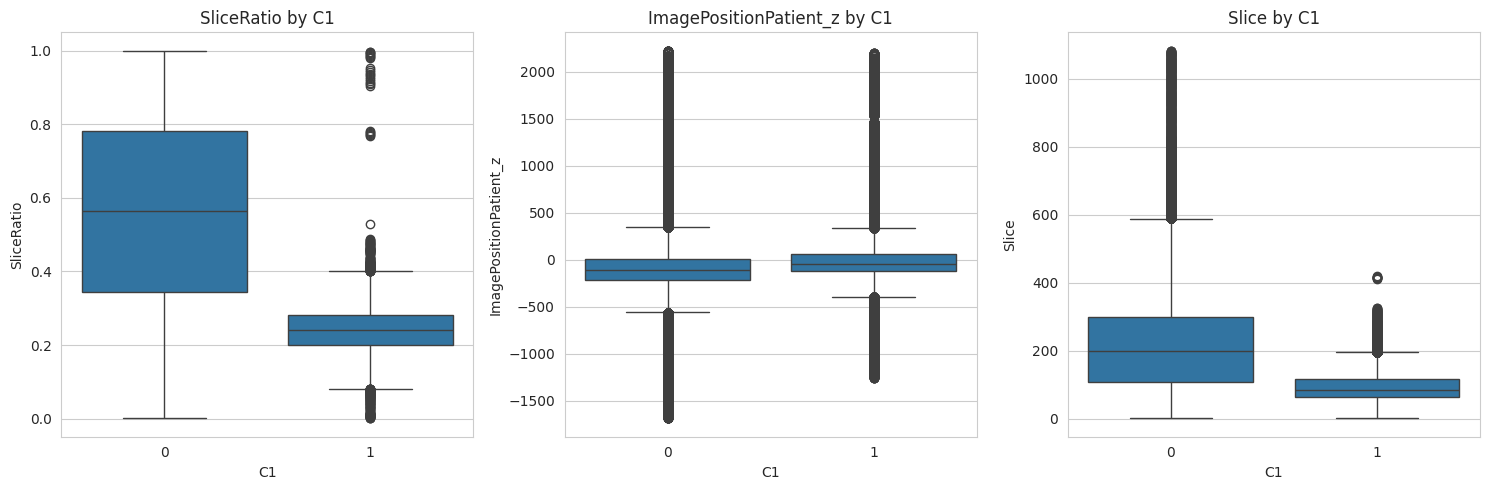

In [27]:
# Features selected for relationship analysis

selected_features = [
    'SliceRatio',
    'ImagePositionPatient_z',
    'Slice'
]


# Grouped boxplots

plt.figure(figsize=(15,5))

for i, feature in enumerate(selected_features):

    plt.subplot(1,3,i+1)

    sns.boxplot(
        data=df,
        x='C1',
        y=feature
    )

    plt.title(f"{feature} by C1")

plt.tight_layout()
plt.show()

# Bivariate Analysis

Grouped boxplots were used to explore the relationship between important numerical features and the target variable (C1).

The following features were selected:

- SliceRatio
- ImagePositionPatient_z
- Slice

These features were selected because previous analysis showed strong correlations and anatomical relevance.

---

## 1. SliceRatio vs C1

A clear separation is observed between the two classes.

Slices where C1 = 1 generally occur at lower SliceRatio values compared to C1 = 0.

This suggests that vertebra C1 appears in specific anatomical regions of the scan.

---

## 2. ImagePositionPatient_z vs C1

Differences are observed between the spatial depth distributions of the two classes.

This indicates that vertebra C1 appears at specific Z-axis positions.

This is anatomically meaningful.

---

## 3. Slice vs C1

The slice numbers for C1 = 1 are concentrated in lower slice ranges compared to C1 = 0.

This suggests that vertebra C1 appears more frequently in specific slices of the scan.

---

## Conclusion

These results indicate that anatomical position features are strongly associated with vertebra visibility.

This suggests that slice location and spatial coordinates may be highly predictive features in later machine learning phases.

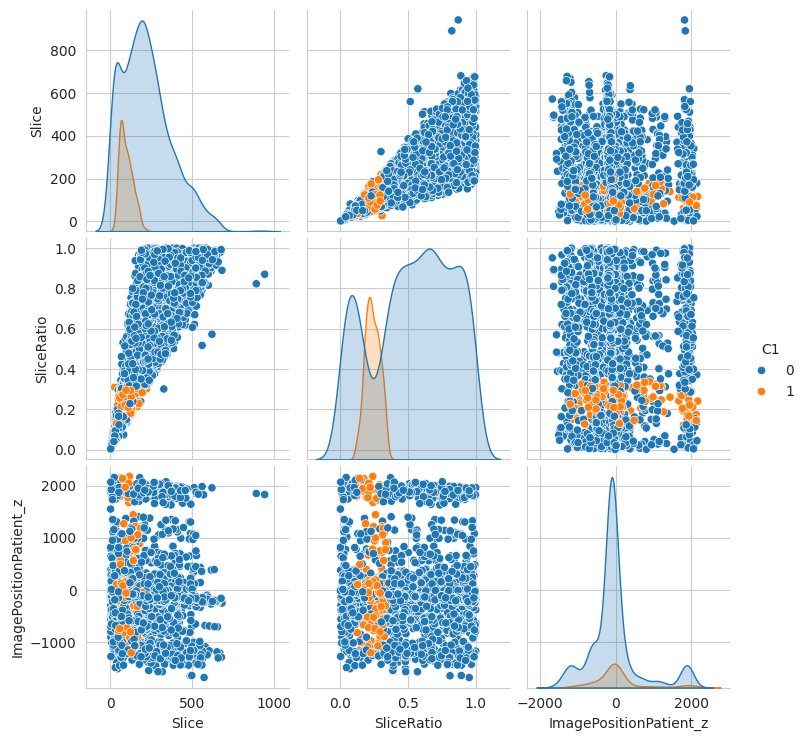

In [28]:
# Pair plot for multivariate analysis

pairplot_features = [
    'Slice',
    'SliceRatio',
    'ImagePositionPatient_z',
    'C1'
]

sns.pairplot(
    df[pairplot_features].sample(3000),
    hue='C1'
)

plt.show()

# Multivariate Analysis

A pair plot was generated using selected anatomical and positional features:

- Slice
- SliceRatio
- ImagePositionPatient_z

The target variable used was:

- C1 (vertebra visibility)

A random sample of 3000 observations was used for visualization efficiency.

---

## Key Observations

### 1. Slice vs SliceRatio

A strong positive relationship is observed between Slice and SliceRatio.

This confirms the correlation analysis, where both features showed strong positive correlation.

As slice number increases, the normalized slice ratio also increases.

---

### 2. Class Separation

The positive class (C1 = 1) appears concentrated in specific regions of the feature space.

This suggests that vertebra C1 is associated with specific anatomical slice locations.

---

### 3. ImagePositionPatient_z

The positive class also appears concentrated at specific Z-axis positions.

This indicates that anatomical depth is strongly related to vertebra visibility.

---

### Overall Conclusion

The pair plot confirms that anatomical position features contain useful predictive information.

The target variable is not randomly distributed.

Instead, vertebra visibility is strongly associated with:

- Slice location
- Relative slice position
- Spatial anatomical coordinates

These features are expected to be valuable for machine learning in later project phases.

# Final Summary and Conclusions

In this phase, Exploratory Data Analysis (EDA) was performed on the RSNA 2022 Spine Fracture Detection metadata dataset.

The objective of this phase was to understand the dataset structure, quality, statistical properties, feature distributions, and relationships before applying machine learning or data mining techniques.

---

## Main Findings

### 1. Dataset Structure

The dataset contains:

- **711,601 CT scan slices**
- **16 features**
- **2019 unique CT studies**

The features include:

- Scan identifiers
- Image dimensions
- Slice thickness
- Spatial coordinates
- Relative slice position
- Vertebra labels (C1–C7)

This dataset belongs to the medical imaging domain and focuses on cervical spine analysis.

---

### 2. Data Quality

The dataset showed excellent data quality:

- **No missing values**
- **No duplicate records**
- **No major inconsistencies**

This indicates that the dataset is well-prepared for further analysis and modeling.

---

### 3. Class Distribution

The vertebra labels (C1–C7) showed **imbalanced binary distributions**.

Most slices belong to class:

- **0 = Vertebra not visible**

while fewer slices belong to:

- **1 = Vertebra visible**

This class imbalance is expected in medical imaging datasets.

---

### 4. Statistical Analysis

Statistical summaries revealed:

- Variable slice counts across studies
- Different scan resolutions (512 and 768 pixels)
- Multiple slice thickness protocols
- Large spatial variation across patient coordinates

These variations reflect real-world differences in CT acquisition protocols.

---

### 5. Outlier Detection

Outliers were detected mainly in:

- ImagePositionPatient_x
- ImagePositionPatient_z

These outliers are likely due to anatomical and scanning variations rather than data errors.

No immediate removal is recommended.

---

### 6. Feature Distributions

Most numerical features did not follow normal distributions.

Several features showed:

- Skewness
- Multimodality
- Scanner-specific clustering

This is expected in medical imaging datasets collected from multiple studies.

---

### 7. Correlation Analysis

Strong correlations were identified between:

- **Slice and SliceRatio** (r ≈ 0.81)
- **ImageHeight and ImageWidth** (r ≈ 1.00)

This suggests possible feature redundancy.

Moderate correlations between neighboring vertebra labels were also observed, which is anatomically meaningful.

---

### 8. Feature Relationships

Bivariate and multivariate analysis showed that vertebra visibility is strongly associated with:

- Slice location
- Relative slice position
- Spatial anatomical coordinates

This indicates that positional features may be highly informative for future machine learning models.

---

# Final Conclusion

The dataset is clean, well-structured, and highly suitable for machine learning applications.

The exploratory analysis revealed strong anatomical and positional relationships with vertebra labels.

In the next project phases, the dataset can be prepared for predictive modeling using:

- Feature engineering
- Feature selection
- Class imbalance handling
- Machine learning classification models

This phase successfully established a strong understanding of the dataset and prepared the foundation for future data mining tasks.